In [1]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
import re

In [2]:
data = pd.read_csv('LDA topics.csv')

In [3]:
pd.DataFrame(data.groupby(by=['topic_job_category','topic_job'])['jobNo'].size()).reset_index()

,topic_job_category,topic_job,jobNo
0,BA,策略顧問,115
1,BA,運營流程分析師,62
2,DA,數據分析師,280
3,DA,行銷分析師,183
4,DE,系統分析師,188
5,DE,資料工程師,220
6,DS,資料科學家,261
7,ML,AI 應用開發者,162
8,ML,AI 演算法工程師,257
9,ML,機器學習工程師,226


In [4]:
# 將整個欄位轉回 list 物件
data['terms'] = data['terms'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [5]:
data.columns

Index(['jobType', 'jobNo', 'jobName', 'jobRole', 'jobRo', 'jobAddrNoDesc',
       'jobAddress', 'descWithoutHighlight', 'optionEdu', 'period',
       'periodDesc', 'applyCnt', 'applyType', 'applyDesc', 'custNo',
       'custName', 'coIndustry', 'coIndustryDesc', 'salaryDesc', 'landmark',
       'jobsource', 'lon', 'lat', 'remoteWorkType', 'major', 'salaryType',
       'dist', 'mrt', 'mrtDesc', 'query', 'min_salary', 'max_salary',
       'emp_desc', 'emp_param', 'zone_desc', 'zoneForeign_desc', 'remote_desc',
       'employees', 'job_category', 'major_資訊工程相關', 'major_資訊管理相關',
       'major_電機電子工程相關', 'major_數學及電算機科學學科類', 'major_數理統計相關',
       'major_其他數學及電算機科學相關', 'major_統計學相關', 'major_商業及管理學科類', 'major_工程學科類',
       'major_應用數學相關', 'major_財稅金融相關', 'major_工業工程相關', 'major_一般商業學類',
       'major_會計學相關', 'major_機械工程相關', 'text_normalized', 'terms', 'topic_id',
       'topic_name', 'topic_job', 'topic_job_category'],
      dtype='object')

In [6]:
font_path = "C:/Windows/Fonts/msjh.ttc"
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 微軟正黑體
plt.rcParams['axes.unicode_minus'] = False  # 正負號也要支援中文

In [9]:
jobs = dict(data[['topic_id', 'topic_job']].drop_duplicates().values)
topics = dict(data[['topic_id', 'topic_name']].drop_duplicates().values)
category = list(data['topic_job_category'].unique())

In [10]:
category

['DA', 'BA', 'DE', 'ML', 'DS']

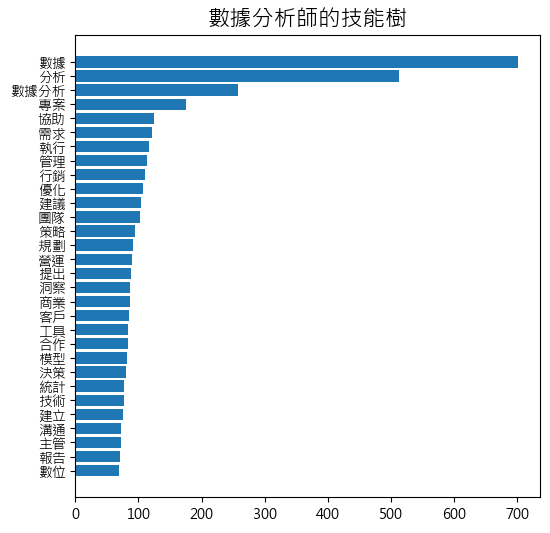

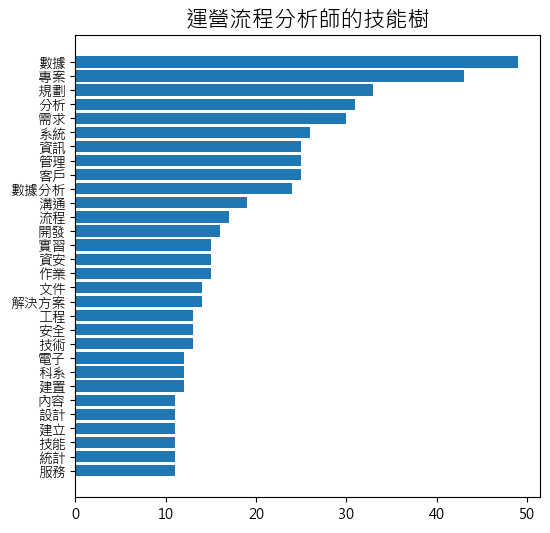

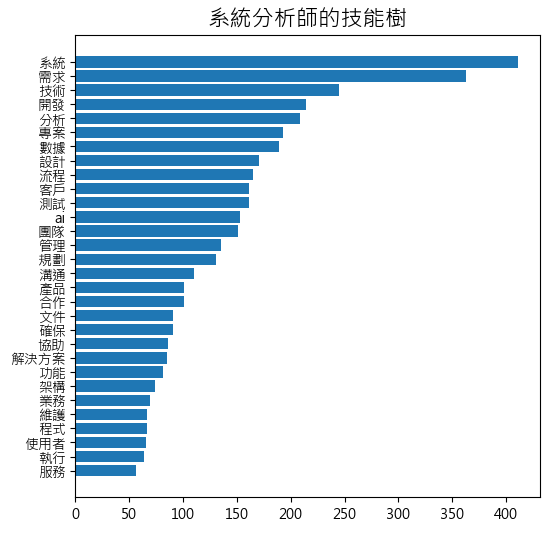

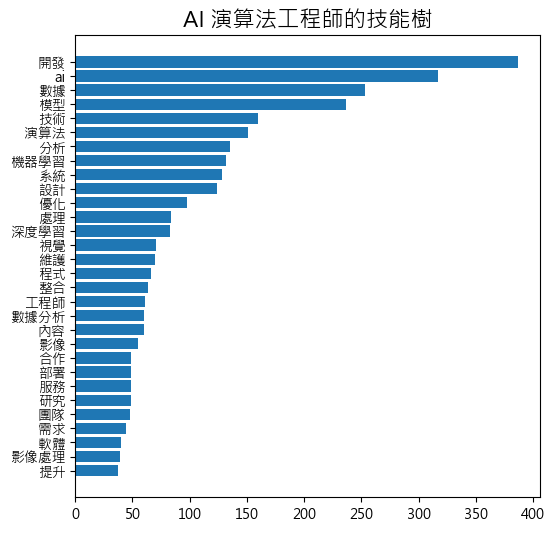

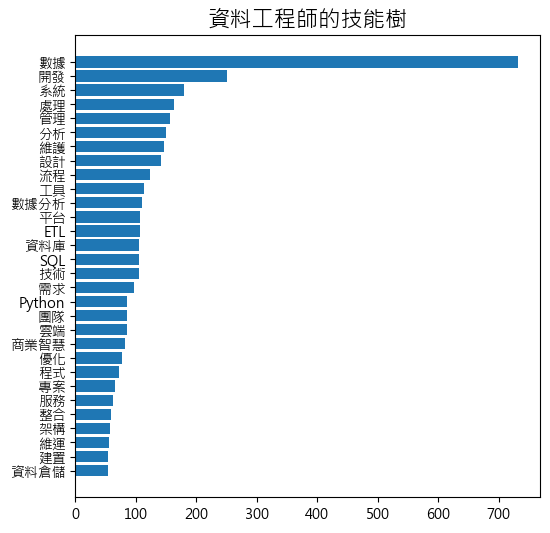

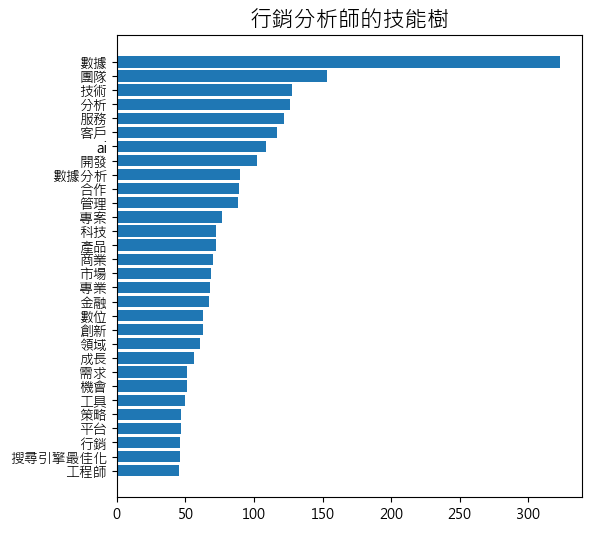

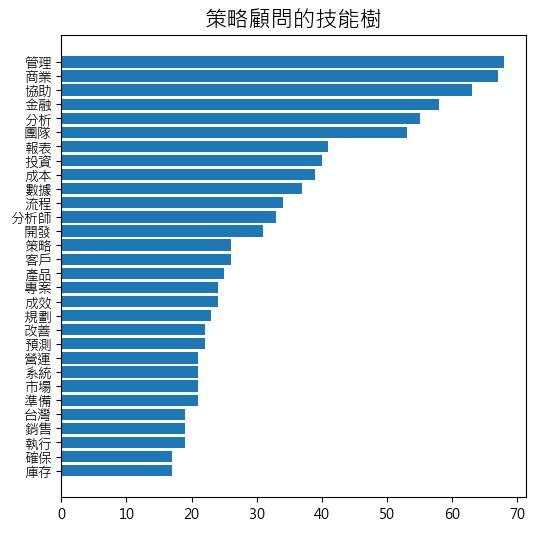

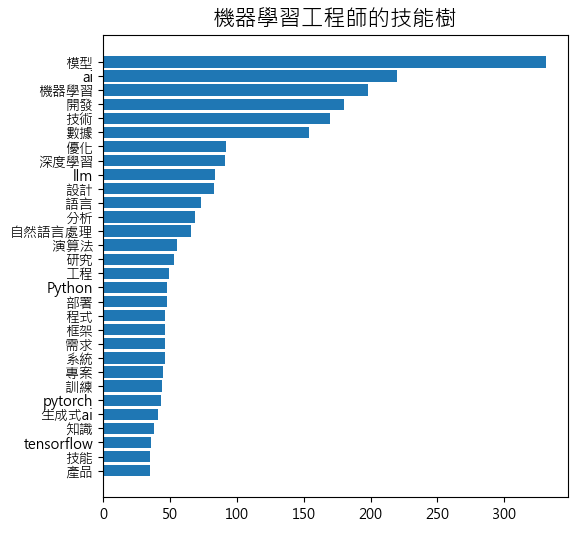

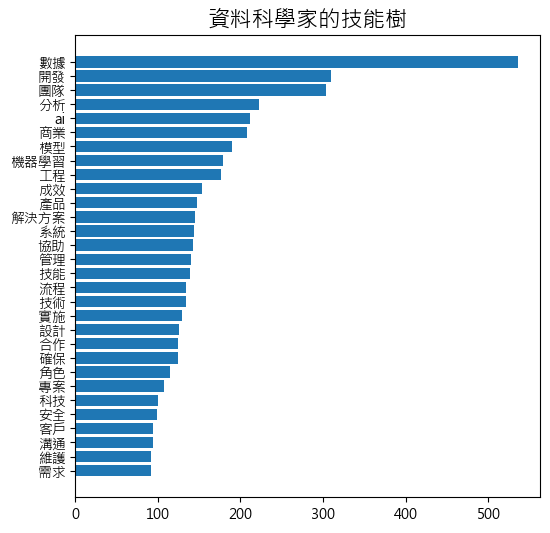

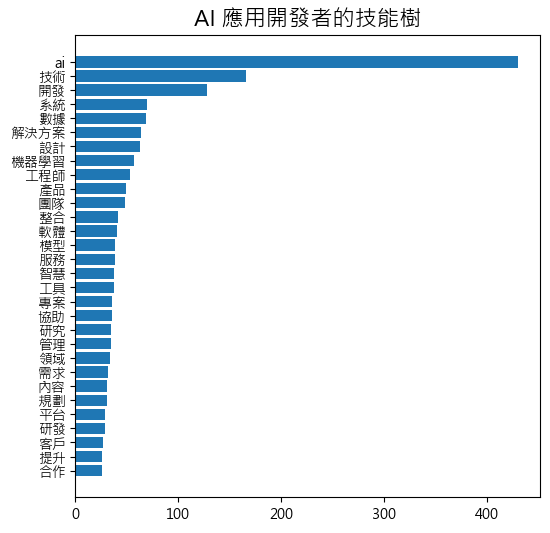

In [8]:
for i in jobs.keys():
    terms = data[data['topic_id'] == i]['terms'].sum()
    text = re.sub(r"\'|\[|\]|,","", str(terms))
    wordcloud = WordCloud(
        font_path=font_path, width=800, height=400, background_color='white', collocations=False
    ).generate(text)
    
    freq = Counter(terms)
    top_n = freq.most_common(30)  # 取出前10高頻詞
#     print(top_n)

    label, vals = zip(*top_n)

    plt.figure(figsize=(6,6))
    plt.barh(label,vals)
    plt.title(f"{jobs[i]}的技能樹", fontsize=16)
    plt.gca().invert_yaxis()
    # plt.xticks(rotation=90)
    plt.show()
    plt.close()
    
#     plt.figure(figsize=(10,5))
#     plt.imshow(wordcloud, interpolation='bilinear')
#     plt.axis('off')
#     plt.title(f"{jobs[i]}的技能字詞雲", fontsize=16)
#     # 儲存圖片
#     plt.tight_layout()
#     plt.savefig(f"{jobs[i]}的技能字詞雲.png", dpi=300)  # 解析度可自訂
#     plt.close()

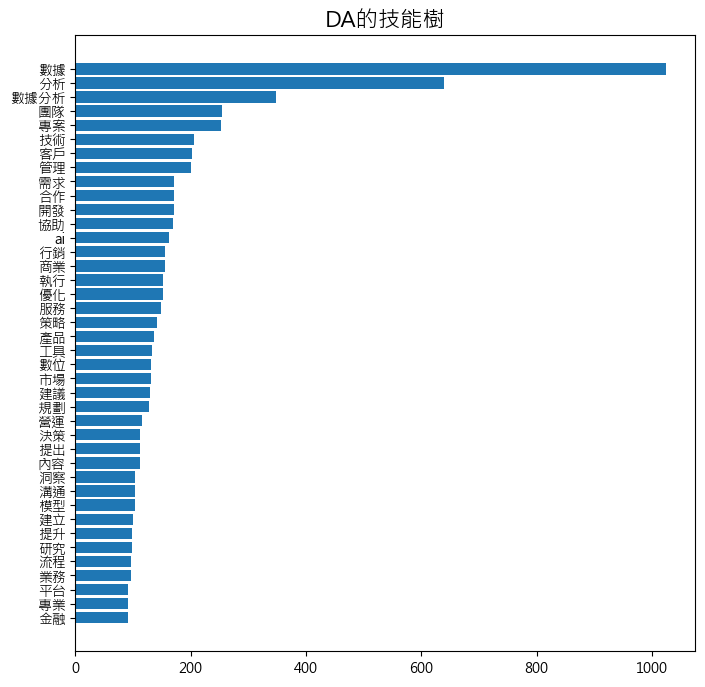

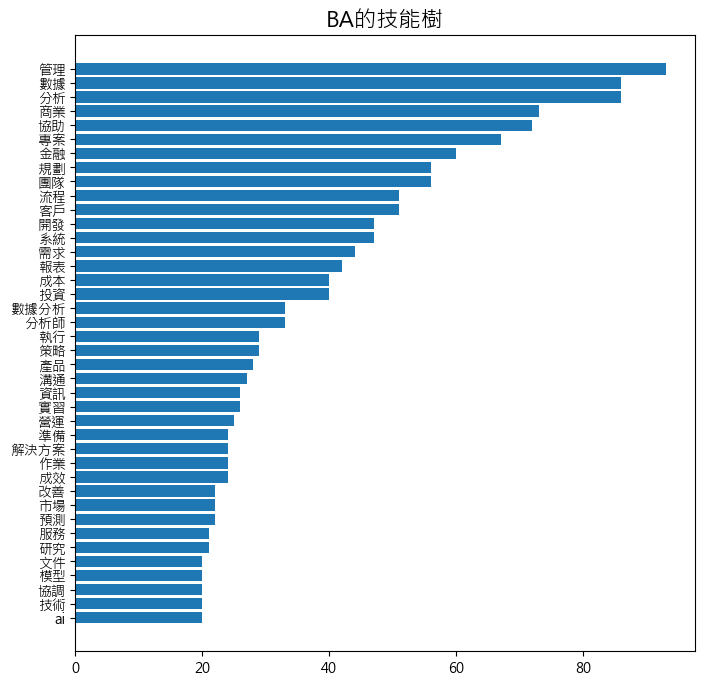

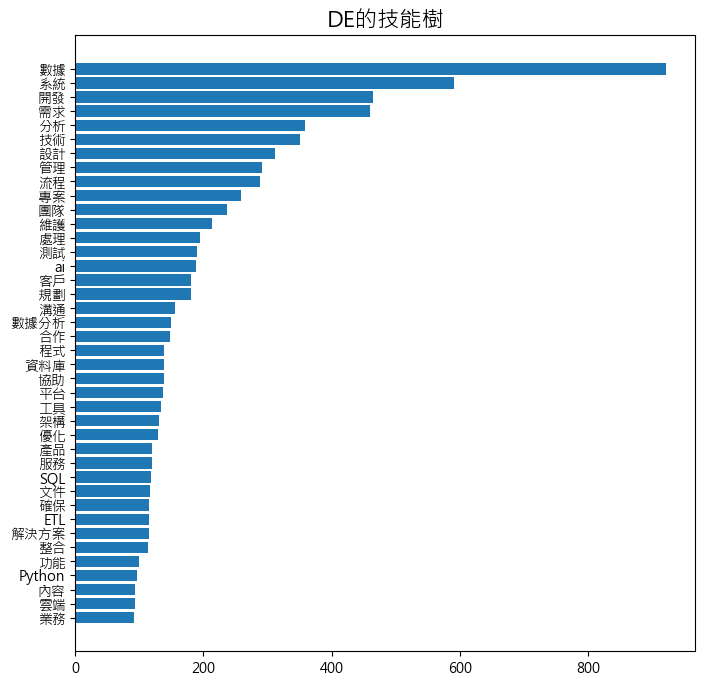

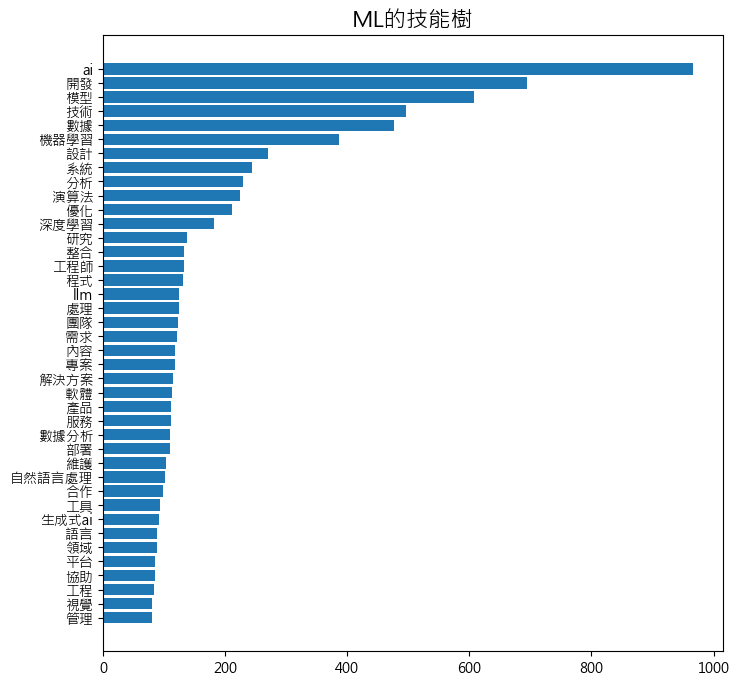

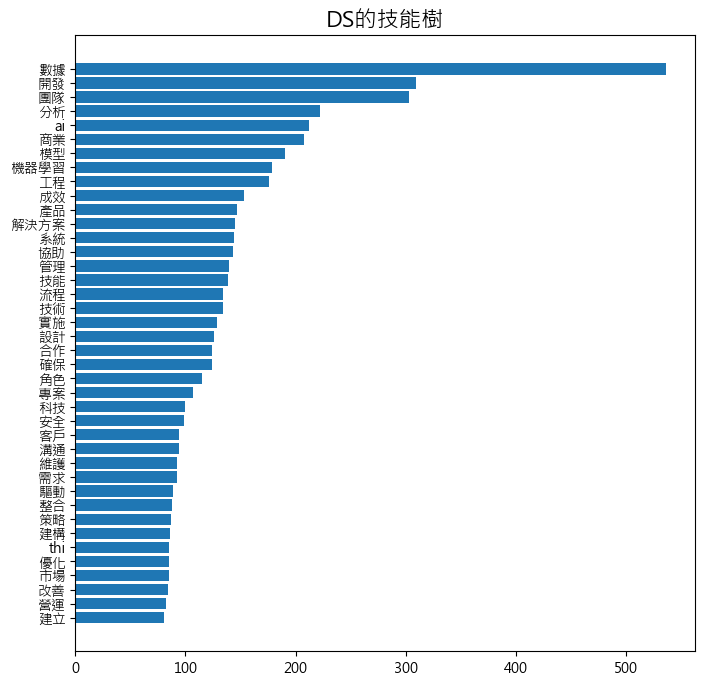

In [14]:
for i in category:
    terms = data[data['topic_job_category'] == i]['terms'].sum()
    text = re.sub(r"\'|\[|\]|,","", str(terms))
    wordcloud = WordCloud(
        font_path=font_path, width=800, height=400, background_color='white', collocations=False
    ).generate(text)
    
    freq = Counter(terms)
    top_n = freq.most_common(40)  # 取出前10高頻詞
#     print(top_n)

    label, vals = zip(*top_n)

    plt.figure(figsize=(8,8))
    plt.barh(label,vals)
    plt.title(f"{i}的技能樹", fontsize=16)
    plt.gca().invert_yaxis()
    # plt.xticks(rotation=90)
    plt.show()
    plt.close()
    
#     plt.figure(figsize=(10,5))
#     plt.imshow(wordcloud, interpolation='bilinear')
#     plt.axis('off')
#     plt.title(f"{jobs[i]}的技能字詞雲", fontsize=16)
#     # 儲存圖片
#     plt.tight_layout()
#     plt.savefig(f"{jobs[i]}的技能字詞雲.png", dpi=300)  # 解析度可自訂
#     plt.close()

In [15]:
data[(data['max_salary'] > 0)&(data['max_salary'] < 500000)].groupby(by=['topic_job']).agg({
    'jobNo': 'size',
    'min_salary': 'mean',
    'max_salary': 'mean'
}).sort_values(by='min_salary', ascending=False)

,jobNo,min_salary,max_salary
topic_job,,,
資料科學家,39,67783.051282,111219.769231
AI 應用開發者,18,62870.370370,101037.037037
機器學習工程師,37,60312.864865,113297.027027
策略顧問,10,58406.666667,88256.666667
系統分析師,31,49390.322581,80745.161290
行銷分析師,41,46771.544715,67404.878049
AI 演算法工程師,52,44595.224359,68050.256410
資料工程師,54,44014.382716,70737.617284
數據分析師,71,38984.882629,57619.201878
